## Does public attention explain market behavior?

The README's original question asks whether public attention or social-media factors help explain market movements beyond performance alone &mdash; that's been an open item since the very first data pull, since no social/attention data source has ever been identified.

But there's already a real, revealed-preference attention signal sitting unused in every notebook so far: Kalshi's own `volume` and `open_interest` columns. Actual money changing hands is arguably a *better* attention proxy for a prediction-market study than social buzz would be. Two questions, using data already on hand:

1. **Which matches/stages of the tournament actually draw trading volume?** (a sanity check that turns up a real surprise)
2. **Does a bigger volume spike around a goal predict a bigger price reaction, or a more likely reversal?** (extends `overreaction_analysis.ipynb`'s goal event-study with an attention dimension)

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Notebook lives in code/, so data/ and output/ live one level up.
ROOT = Path.cwd().parent
FIG_DIR = ROOT / "output" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEAM_NAME_ALIASES = {
    "Cape Verde": "Cabo Verde",
    "Bosnia and Herzegovina": "Bosnia & Herzegovina",
    "Congo DR": "DR Congo",
    "Ivory Coast": "C\u00f4te d'Ivoire",
    "IR Iran": "Iran",
    "Turkiye": "T\u00fcrkiye",
    "Curacao": "Cura\u00e7ao",
    "Korea Republic": "South Korea",
}
REVERSE_ALIASES = {v: k for k, v in TEAM_NAME_ALIASES.items()}

markets = pd.read_parquet(ROOT / "data/kalshi/kxwcgame_markets.parquet")
candles = pd.read_parquet(ROOT / "data/kalshi/candlesticks/kxwcgame_minute.parquet")
schedule = pd.read_parquet(ROOT / "data/sofascore/schedule.parquet")
incidents = pd.read_parquet(ROOT / "data/sofascore/incidents.parquet")

In [2]:
def price_at(grp: pd.DataFrame, kickoff: pd.Timestamp, target_min: float) -> float:
    target_ts = kickoff + pd.Timedelta(minutes=target_min)
    before = grp[grp["timestamp"] <= target_ts]
    return before["price_close"].iloc[-1] if len(before) else np.nan


def volume_rate(grp: pd.DataFrame, kickoff: pd.Timestamp, start_min: float, end_min: float) -> tuple[float, int]:
    start_ts, end_ts = kickoff + pd.Timedelta(minutes=start_min), kickoff + pd.Timedelta(minutes=end_min)
    win = grp[(grp["timestamp"] > start_ts) & (grp["timestamp"] <= end_ts)]
    return (win["volume"].mean(), len(win)) if len(win) else (np.nan, 0)


### Part 1: which matches actually draw volume?

Naive guess going in: attention should build toward the final. Testing that directly, by tournament stage.

In [3]:
STAGE_ORDER = [
    "Group stage", "Round of 32", "Round of 16", "Quarterfinals",
    "Semifinals", "Match for 3rd place", "Final",
]

sched = schedule.copy()
sched["stage"] = sched["round_name"].fillna("Group stage")
sched["team_set"] = [frozenset(t) for t in zip(sched["home_team"], sched["away_team"])]

parts = markets["event_title"].str.split(" vs ", n=1, expand=True)
markets["team_set"] = [
    frozenset(t)
    for t in zip(
        parts[0].str.strip().replace(TEAM_NAME_ALIASES),
        parts[1].str.split(":").str[0].str.strip().replace(TEAM_NAME_ALIASES),
    )
]

by_match = markets.groupby("event_ticker").agg(volume=("volume", "sum"), team_set=("team_set", "first")).reset_index()
before = len(by_match)
by_match = by_match.merge(sched[["team_set", "stage"]], on="team_set", how="left")
print(f"by_match merge sched: {before} rows -> {len(by_match)} rows")

stage_summary = by_match.groupby("stage")["volume"].agg(["mean", "median", "count"]).reindex(STAGE_ORDER)

ranked = by_match.sort_values("volume", ascending=False).reset_index(drop=True)
final_rank = ranked.index[ranked["stage"] == "Final"][0] + 1
print(f"the Final ranks #{final_rank} of {len(ranked)} matches by total volume")
stage_summary

by_match merge sched: 104 rows -> 104 rows
the Final ranks #59 of 104 matches by total volume


,mean,median,count
stage,,,
Group stage,5.168825e+07,5.055791e+07,72
Round of 32,2.067647e+07,2.035050e+07,16
Round of 16,2.474704e+07,2.070951e+07,8
Quarterfinals,2.727099e+07,2.820434e+07,4
Semifinals,2.993502e+07,2.993502e+07,2
Match for 3rd place,4.113821e+07,4.113821e+07,1
Final,3.428729e+07,3.428729e+07,1


Saved /Users/katemarine/Documents/wc26-prediction-markets/output/figures/attention_by_stage.png


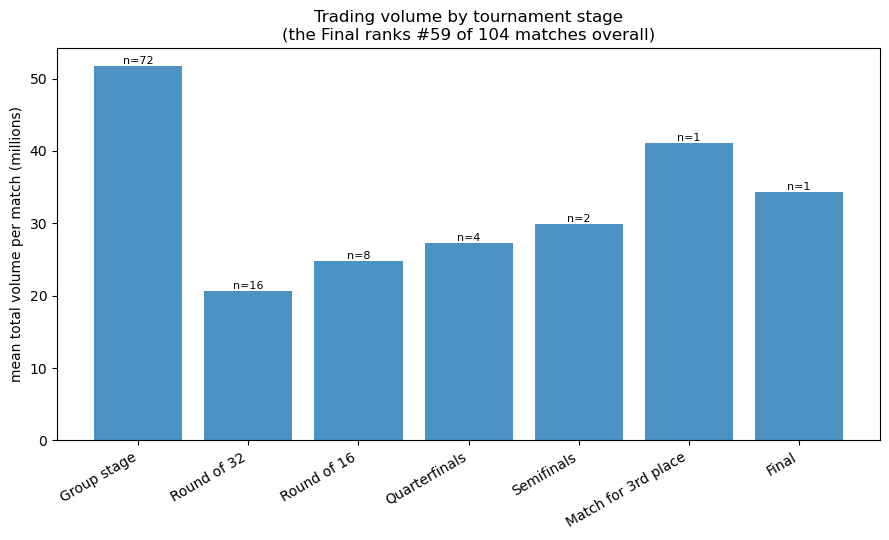

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(STAGE_ORDER))
bars = ax.bar(x, stage_summary["mean"] / 1e6, color="tab:blue", alpha=0.8)
for xi, (mean_v, n) in zip(x, zip(stage_summary["mean"], stage_summary["count"])):
    ax.annotate(f"n={int(n)}", (xi, mean_v / 1e6), ha="center", va="bottom", fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(STAGE_ORDER, rotation=30, ha="right")
ax.set_ylabel("mean total volume per match (millions)")
ax.set_title(f"Trading volume by tournament stage\n(the Final ranks #{final_rank} of {len(ranked)} matches overall)")

fig.tight_layout()
out_path = FIG_DIR / "attention_by_stage.png"
fig.savefig(out_path, dpi=150)
print(f"Saved {out_path}")

### Part 2: does a bigger attention spike mean a bigger (or more reversible) price reaction?

Reuses `overreaction_analysis.ipynb`'s goal-matching and first-half-only windowing (same reasoning: SofaScore's match-minute can't be mapped to real elapsed time past the unmodeled halftime break), extended with a volume measure:

- **`spike_ratio`** = (per-minute trading volume in the 4 min after the goal) &divide; (per-minute volume in a 10-minute baseline window before the goal, ending 2 min pre-goal). A ratio of 3 means trading ran at 3&times; the pre-goal rate right after the goal.

In [5]:
goals = incidents[incidents["incident_type"] == "goal"].copy()
before = len(goals)
goals = goals.merge(sched[["event_id", "home_team", "away_team"]], on="event_id", how="left")
print(f"goals merge sched: {before} rows -> {len(goals)} rows")
goals["scoring_team_sofa"] = np.where(goals["is_home"], goals["home_team"], goals["away_team"])
goals["scoring_team_kalshi"] = goals["scoring_team_sofa"].map(lambda x: REVERSE_ALIASES.get(x, x))

markets["subtitle_clean"] = markets["yes_team_subtitle"].str.replace("Reg Time: ", "", regex=False).str.strip()
markets_unique = markets[["event_ticker", "team_set"]].drop_duplicates()
before = len(markets_unique)
market_to_event = markets_unique.merge(
    sched[["team_set", "event_id", "start_time"]], on="team_set", how="left"
)
print(f"markets merge sched: {before} rows -> {len(market_to_event)} rows")
before = len(goals)
goals = goals.merge(market_to_event[["event_id", "event_ticker", "start_time"]], on="event_id", how="left")
print(f"goals merge market_to_event: {before} rows -> {len(goals)} rows")

team_ticker_lookup = markets.set_index(["event_ticker", "subtitle_clean"])["market_ticker"].to_dict()
goals["market_ticker"] = [
    team_ticker_lookup.get((et, team)) for et, team in zip(goals["event_ticker"], goals["scoring_team_kalshi"])
]

goals["t0"] = goals["time"] + goals["added_time"].fillna(0)
BEFORE_MIN, SHORT_MIN, LONG_MIN, BASELINE_MIN = 2, 4, 10, 12
usable_goals = goals[
    (goals["time"] <= 45) & (goals["t0"] >= BASELINE_MIN) & (goals["t0"] + LONG_MIN <= 45)
].copy()
print(f"usable first-half goals: {len(usable_goals)} / {len(goals)} total goals")

goals merge sched: 308 rows -> 308 rows
markets merge sched: 104 rows -> 104 rows
goals merge market_to_event: 308 rows -> 308 rows
usable first-half goals: 52 / 308 total goals


In [6]:
candles_by_ticker = {t: g.sort_values("timestamp") for t, g in candles.groupby("market_ticker")}


rows = []
for g in usable_goals.itertuples():
    grp = candles_by_ticker.get(g.market_ticker)
    if grp is None:
        continue
    pre = price_at(grp, g.start_time, g.t0 - BEFORE_MIN)
    short = price_at(grp, g.start_time, g.t0 + SHORT_MIN)
    long_ = price_at(grp, g.start_time, g.t0 + LONG_MIN)
    baseline_rate, baseline_n = volume_rate(grp, g.start_time, g.t0 - BASELINE_MIN, g.t0 - BEFORE_MIN)
    spike_rate, spike_n = volume_rate(grp, g.start_time, g.t0, g.t0 + SHORT_MIN)
    if any(pd.isna(x) for x in (pre, short, long_, baseline_rate, spike_rate)):
        continue
    rows.append(
        {
            "event_id": g.event_id,
            "jump": short - pre,
            "drift": long_ - short,
            "spike_ratio": spike_rate / (baseline_rate + 1),  # +1 avoids blowing up on near-zero baselines
        }
    )

reactions = pd.DataFrame(rows)
reactions["reversion"] = np.nan
nontrivial = reactions[reactions["jump"].abs() > 0.02].copy()
nontrivial["reversion"] = ((nontrivial["jump"] > 0) & (nontrivial["drift"] < 0)) | (
    (nontrivial["jump"] < 0) & (nontrivial["drift"] > 0)
)

print(f"goals with complete price + volume data: {len(reactions)} ({len(nontrivial)} with a non-trivial jump)")
print(f"mean spike_ratio: {reactions['spike_ratio'].mean():.2f} (i.e. trading runs at ~{reactions['spike_ratio'].mean():.1f}x the pre-goal rate)")

r, p = stats.pearsonr(reactions["spike_ratio"], reactions["jump"].abs())
print(f"corr(spike_ratio, |jump|) = {r:+.3f}, p = {p:.3f}")

t, p_t = stats.ttest_ind(
    nontrivial.loc[nontrivial["reversion"], "spike_ratio"],
    nontrivial.loc[~nontrivial["reversion"], "spike_ratio"],
    equal_var=False,
)
print(f"reverting vs. continuing goals, mean spike_ratio: {nontrivial.groupby('reversion')['spike_ratio'].mean().to_dict()}, t-test p = {p_t:.3f}")

goals with complete price + volume data: 52 (45 with a non-trivial jump)
mean spike_ratio: 3.57 (i.e. trading runs at ~3.6x the pre-goal rate)
corr(spike_ratio, |jump|) = +0.286, p = 0.040
reverting vs. continuing goals, mean spike_ratio: {False: 3.7684714927487213, True: 3.3027192713773643}, t-test p = 0.646


Saved /Users/katemarine/Documents/wc26-prediction-markets/output/figures/attention_vs_reaction.png


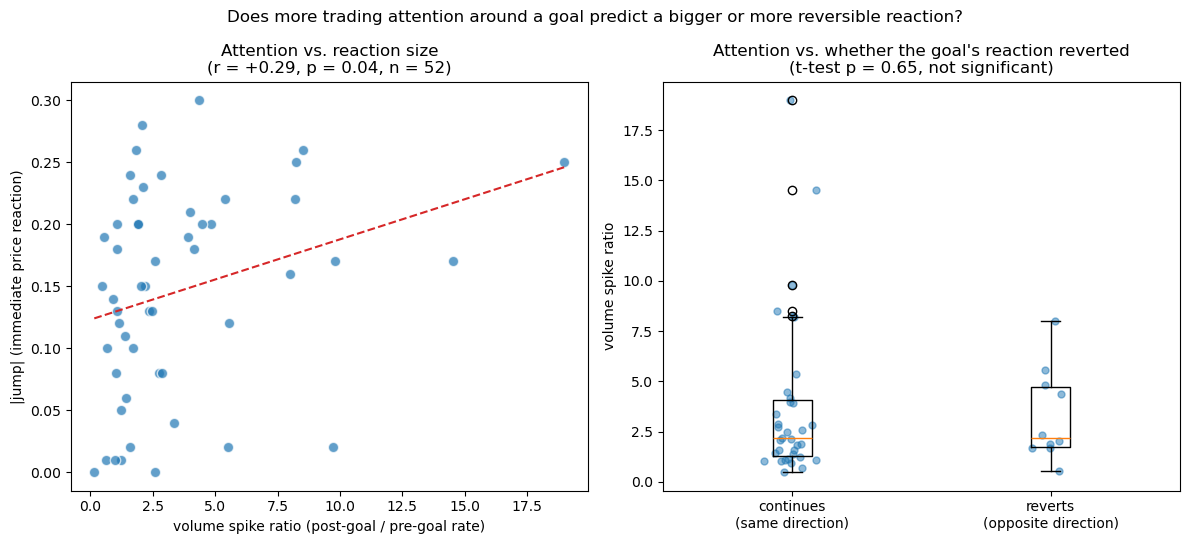

In [7]:
fig, (ax_scatter, ax_box) = plt.subplots(1, 2, figsize=(12, 5.5))

ax_scatter.scatter(reactions["spike_ratio"], reactions["jump"].abs(), alpha=0.7, edgecolor="white", s=55)
z = np.polyfit(reactions["spike_ratio"], reactions["jump"].abs(), 1)
xs = np.linspace(reactions["spike_ratio"].min(), reactions["spike_ratio"].max(), 50)
ax_scatter.plot(xs, np.polyval(z, xs), color="tab:red", linestyle="--", linewidth=1.5)
ax_scatter.set_xlabel("volume spike ratio (post-goal / pre-goal rate)")
ax_scatter.set_ylabel("|jump| (immediate price reaction)")
ax_scatter.set_title(f"Attention vs. reaction size\n(r = {r:+.2f}, p = {p:.2f}, n = {len(reactions)})")

groups = [nontrivial.loc[~nontrivial["reversion"], "spike_ratio"], nontrivial.loc[nontrivial["reversion"], "spike_ratio"]]
ax_box.boxplot(groups, tick_labels=["continues\n(same direction)", "reverts\n(opposite direction)"])
for i, g in enumerate(groups, start=1):
    ax_box.scatter(np.random.normal(i, 0.05, len(g)), g, alpha=0.5, s=25, color="tab:blue")
ax_box.set_ylabel("volume spike ratio")
ax_box.set_title(f"Attention vs. whether the goal's reaction reverted\n(t-test p = {p_t:.2f}, not significant)")

fig.suptitle("Does more trading attention around a goal predict a bigger or more reversible reaction?")
fig.tight_layout()
out_path = FIG_DIR / "attention_vs_reaction.png"
fig.savefig(out_path, dpi=150)
print(f"Saved {out_path}")

### Results so far

**Part 1 &mdash; attention is heavily concentrated in the group stage, not the final.** Group-stage matches average ~52M volume units each (Kalshi's raw `volume_fp` field &mdash; its exact contracts-vs-cents convention isn't documented anywhere in the pulled data, so treat this as a relative comparison, not a dollar figure); every knockout round averages 20-41M, well below that, despite (presumably) higher stakes per match. **The final itself ranks only #59 of 104 matches by total volume.** That's the opposite of the naive "attention builds toward the final" intuition.

This can't be fully explained from the data on hand, but a few plausible (untested) mechanisms: the group stage has far more matches running in parallel (72 vs. 32 knockout matches), so it may simply be splitting a bigger, broader pool of casual bettors across more games rather than each game individually drawing less interest; it's also the stage with the most competitive uncertainty (every team is still alive, more genuinely unclear outcomes), while by the final only the two best-performing teams remain and the market may already be more one-sided. Worth treating as a genuine open question rather than a solved one.

**Part 2 &mdash; attention scales with reaction size, but not with whether that reaction reverts.** Goals reliably spike trading (mean spike_ratio = 3.6x the pre-goal rate), confirming volume is a real, responsive attention signal. Bigger volume spikes are associated with bigger immediate price jumps (r = +0.29, p = 0.04, n = 52) &mdash; a modest but statistically real relationship. But spike size does *not* differ between goals whose reaction later reverted vs. continued (p = 0.65) &mdash; attention amplifies how much the market moves, not whether that move turns out to be an overreaction that gets corrected.

**Read together with the other three notebooks:** this is now a fourth independent line of evidence, and it points the same direction as the others &mdash; no sign that higher-attention moments are where this market behaves *worse* (more overreaction-prone). If anything, more trading looks like more (appropriately-sized) price discovery, not more noise.

**Limitations / next steps:**

- n = 52 for Part 2 is small (same first-half-only constraint as `overreaction_analysis.ipynb`, now further tightened by requiring the baseline volume window to also fit before kickoff+halftime). The correlation is real at conventional significance but shouldn't be over-read at this sample size.
- Part 1's stage-level pattern is observational and confounded with several things at once (number of parallel markets, tournament progression, remaining-team quality) &mdash; a cleaner test would need to isolate these, e.g. by comparing volume *per team still alive* rather than per match.
- The `KXMENWORLDCUP` tournament-winner futures data (hourly, spans the whole tournament) is still completely unused across every notebook so far &mdash; the natural next step is asking whether a team's title odds overreact to a single strong result and partially revert over the following days, which would extend this same attention question to a much longer time horizon.